# Object Detection
## Name - Manan Chahal
## Roll No - 23102C0044

## Traditional meathods

## 1) template Matching

In [80]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import hog
from sklearn.svm import LinearSVC

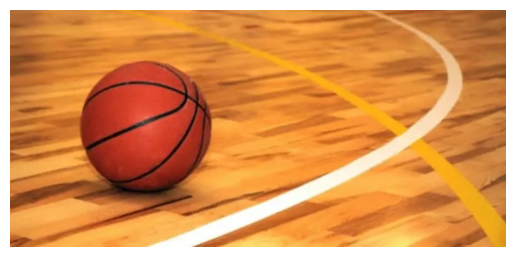

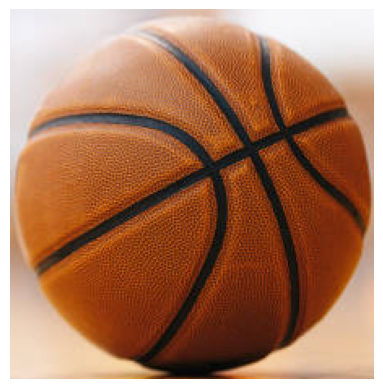

In [55]:
img = cv2.imread('basketball-court.jpeg')
template = cv2.imread('basketball_template.png')

img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
template = cv2.cvtColor(template,cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

plt.imshow(template)
plt.axis('off') 
plt.show()


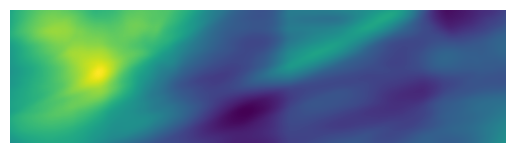

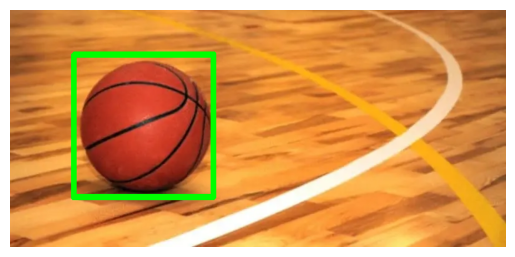

In [56]:
template_obj = cv2.matchTemplate(img, template, cv2.TM_CCOEFF_NORMED)

h, w = template.shape[:2]   # works for color images

plt.imshow(template_obj)
plt.axis('off')
plt.show()

threshold = 0.49
loc = np.where(template_obj >= threshold)
template_img = img.copy()
for pt in zip(*loc[::-1]):
    cv2.rectangle(template_img, pt, (pt[0] + w, pt[1] + h), (0,255,0), 2)

plt.imshow(template_img)
plt.axis('off')
plt.show()

## 2) MultiObject template matching

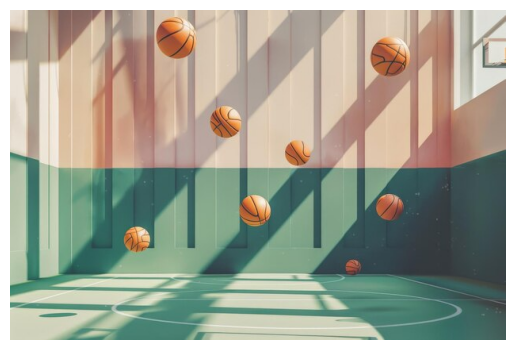

In [69]:
mult_img = cv2.imread('multi-basketball-court.jpeg')
mult_img = cv2.cvtColor(mult_img,cv2.COLOR_BGR2RGB)

plt.imshow(mult_img)
plt.axis('off')
plt.show()

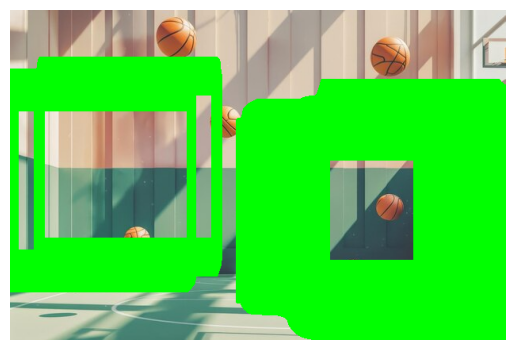

In [86]:
template_obj = cv2.matchTemplate(mult_img, template, cv2.TM_CCOEFF_NORMED)

h, w = template.shape[:2]   # works for color images

#plt.imshow(template_obj)
#plt.axis('off')
#plt.show()

threshold = 0.38
loc = np.where(template_obj >= threshold)
template_img = mult_img.copy()
for pt in zip(*loc[::-1]):
    cv2.rectangle(template_img, pt, (pt[0] + w, pt[1] + h), (0,255,0), 2)

plt.imshow(template_img)
plt.axis('off')
plt.show()

# Orb

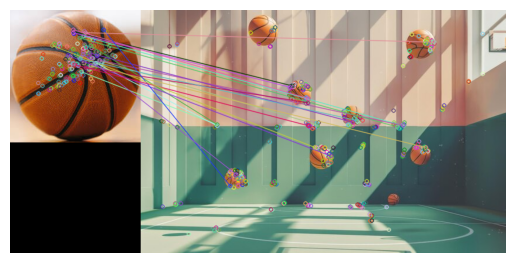

In [76]:
orb = cv2.ORB_create()

kp1, des1 = orb.detectAndCompute(template, None)
kp2, des2 = orb.detectAndCompute(mult_img, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)

matches = sorted(matches, key=lambda x: x.distance)

img_matches = cv2.drawMatches(template, kp1, mult_img, kp2, matches[:20], None)

plt.imshow(img_matches)
plt.axis("off")
plt.show()

## Methodology and Results

### Template Matching Overview

Template matching is a basic image processing technique used to locate a smaller image (template) within a larger image. It works by sliding the template across the image and comparing pixel values at each position. We used `cv2.TM_CCOEFF_NORMED`, where higher values indicate better matches.

### Application: Basketball Court Detection

We applied template matching to detect basketball courts:

- **Image Preparation**: Loaded images using `cv2.imread()` and converted them from BGR to RGB for display.
- **Matching**: Used `cv2.matchTemplate()` to compute similarity between the template and the image.
- **Thresholding**:  
  - Single object: `0.49` (more precise)  
  - Multiple objects: `0.38` (captures more instances)
- **Bounding Boxes**: Used `np.where()` to find matches and drew rectangles using `cv2.rectangle()`.

### Results

- **Single Object Detection**:  
  Successfully detected the basketball court with a clear and accurate bounding box at a threshold of `0.49`.

- **Multi-Object Detection**:  
  Lowering the threshold to `0.38` helped detect multiple courts. However, this can introduce less precise detections or false positives.

### Effectiveness and Limitations

**Pros**
- Simple and easy to implement  
- Fast for small images  
- Accurate when objects closely match the template  

**Cons**
- Sensitive to scale, rotation, and lighting changes  
- Not robust to occlusion or variations  
- Can be computationally expensive for large images  
- Requires careful threshold tuning  

### Conclusion

Template matching works well for detecting identical objects in controlled conditions. However, due to its sensitivity to variations, it is less reliable for real-world scenarios. More advanced methods like feature-based matching (e.g., ORB) or deep learning models are better suited for robust object detection.